<a href="https://colab.research.google.com/github/Janpu-Hou/Green-Learning-Basic/blob/main/SLM_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. Subspace Learning Machine (SLM) Core
# ==========================================
class SLMNode:
    def __init__(self, depth=0):
        self.depth = depth
        self.is_leaf = False
        self.prediction = None
        self.projection_vector = None
        self.threshold = None
        self.left = None
        self.right = None

class SubspaceLearningMachine:
    def __init__(self, max_depth=5, min_samples=5, num_projections=15, B_bins=16, beta=0.5):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.num_projections = num_projections
        self.B_bins = B_bins
        self.beta = beta
        self.root = None

    def _calculate_entropy(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y)
        probabilities = counts / len(y)
        return entropy(probabilities, base=2)

    def _probabilistic_projection_vectors(self, D):
        d_indices = np.arange(1, D + 1)
        probabilities = np.exp(-self.beta * d_indices)
        probabilities /= probabilities.sum()

        vectors = []
        for _ in range(self.num_projections):
            mask = np.random.choice([0, 1], size=D, p=[0.5, 0.5])
            a = np.random.randn(D) * probabilities * mask
            norm = np.linalg.norm(a)
            if norm > 0:
                a = a / norm
            vectors.append(a)
        return vectors

    def _discriminant_feature_test(self, X, y, a):
        f_a = np.dot(X, a)
        f_min, f_max = np.min(f_a), np.max(f_a)

        if f_min == f_max:
            return float('inf'), None

        thresholds = np.linspace(f_min, f_max, self.B_bins + 1)[1:-1]
        best_loss = float('inf')
        best_t = None

        for t in thresholds:
            left_mask = f_a >= t
            right_mask = f_a < t

            y_left = y[left_mask]
            y_right = y[right_mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            N = len(y)
            loss = (len(y_left) / N) * self._calculate_entropy(y_left) + \
                   (len(y_right) / N) * self._calculate_entropy(y_right)

            if loss < best_loss:
                best_loss = loss
                best_t = t

        return best_loss, best_t

    def _build_tree(self, X, y, depth):
        node = SLMNode(depth=depth)

        if depth >= self.max_depth or len(y) < self.min_samples or len(set(y)) == 1:
            node.is_leaf = True
            node.prediction = Counter(y).most_common(1)[0][0]
            return node

        D = X.shape[1]
        candidate_vectors = self._probabilistic_projection_vectors(D)

        best_overall_loss = float('inf')
        best_vector = None
        best_threshold = None

        for a in candidate_vectors:
            loss, t = self._discriminant_feature_test(X, y, a)
            if loss < best_overall_loss:
                best_overall_loss = loss
                best_vector = a
                best_threshold = t

        if best_vector is None or best_threshold is None:
            node.is_leaf = True
            node.prediction = Counter(y).most_common(1)[0][0]
            return node

        node.projection_vector = best_vector
        node.threshold = best_threshold

        f_a = np.dot(X, best_vector)
        left_mask = f_a >= best_threshold
        right_mask = f_a < best_threshold

        node.left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return node

    def fit(self, X, y):
        self.root = self._build_tree(np.array(X), np.array(y), depth=0)

    def _predict_sample(self, x, node):
        if node.is_leaf:
            return node.prediction
        projected_val = np.dot(x, node.projection_vector)
        if projected_val >= node.threshold:
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_sample(x, self.root) for x in X])


# ==========================================
# 2. IoT-23 Dataset Processing & Execution
# ==========================================
def load_and_preprocess_iot23(filepaths, sample_size=20000):
    """
    Loads and cleans the IoT-23 network traffic dataset from multiple files.
    Because the raw dataset is massive, we sample it for this pure Python SLM implementation.
    """
    print(f"Loading data from {filepaths}...")

    dfs = []
    for filepath in filepaths:
        try:
            # Load dataset. Depending on the exact Kaggle file, the delimiter might be a comma or a tab.
            # Adjust `nrows` or use `sample` to avoid memory overload on local machines.
            df_single = pd.read_csv(filepath)
            dfs.append(df_single)
        except FileNotFoundError:
            print(f"Error: Could not find '{filepath}'. Skipping this file.")
            continue

    if not dfs:
        raise ValueError("No valid data files found from the provided paths.")

    df = pd.concat(dfs, ignore_index=True)

    # Randomly sample to reduce training time for this baseline script
    if len(df) > sample_size:
        df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

    print("Preprocessing data...")
    # 1. Drop irrelevant columns (IDs, timestamps) that don't help with mathematical projection
    cols_to_drop = ['ts', 'uid', 'id.orig_h', 'id.resp_h', 'detailed-label']
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

    # 2. Handle Zeek's missing value representation ('-')
    df.replace('-', 0, inplace=True)

    # 3. Convert numerical strings to actual floats
    numeric_cols = ['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes',
                    'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # 4. Encode Categorical Variables (proto, service, conn_state)
    categorical_cols = ['proto', 'service', 'conn_state', 'history']
    encoder = LabelEncoder()
    for col in categorical_cols:
        if col in df.columns:
            df[col] = encoder.fit_transform(df[col].astype(str))

    # 5. Encode Target Label (Benign vs Malicious)
    if 'label' in df.columns:
        df['label'] = encoder.fit_transform(df['label'].astype(str))
        y = df['label'].values
        X = df.drop(columns=['label'])
    else:
        raise ValueError("Target column 'label' not found in the dataset.")

    # 6. Scale numerical features (Crucial for SLM's dot product projections)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, encoder

if __name__ == "__main__":
    # ---> UPDATE THIS PATH to point to your Kaggle IoT-23 CSV file <---
    IOT23_DATASET_PATHS = ["/content/iot23_train.csv", "/content/iot23_test.csv"]

    try:
        # Load and preprocess the data
        X, y, label_encoder = load_and_preprocess_iot23(IOT23_DATASET_PATHS, sample_size=10000)

        # Split into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        print(f"Training Data Shape: {X_train.shape}")

        # Initialize the SLM (Hyperparameters can be tuned based on the paper)
        print("Training the Subspace Learning Machine...")
        slm = SubspaceLearningMachine(
            max_depth=8,         # Updated based on hyperparameter tuning
            min_samples=10,
            num_projections=20,  # Updated based on hyperparameter tuning
            beta=0.5
        )

        # Fit the model
        slm.fit(X_train, y_train)
        print("Training complete.")

        # Predict and evaluate
        print("Evaluating model...")
        predictions = slm.predict(X_test)

        # Print metrics
        print("\n--- SLM Performance on IoT-23 ---")
        print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%\n")

        # Decode labels back to original strings for the report
        # Use labels present in y_test for classification_report
        target_names_for_report = label_encoder.inverse_transform(np.unique(y_test))
        print(classification_report(y_test, predictions, labels=np.unique(y_test), target_names=target_names_for_report))

    except ValueError as e:
        print(f"Error during data loading or preprocessing: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


Loading data from ['/content/iot23_train.csv', '/content/iot23_test.csv']...
Preprocessing data...
Training Data Shape: (7000, 35)
Training the Subspace Learning Machine...
Training complete.
Evaluating model...

--- SLM Performance on IoT-23 ---
Accuracy: 83.50%

              precision    recall  f1-score   support

      Attack       0.96      0.98      0.97       139
      Benign       0.85      0.78      0.81      1154
         C&C       0.85      0.41      0.55       239
        DDoS       0.85      0.99      0.91       490
       Okiru       1.00      1.00      1.00       283
    PortScan       0.73      0.87      0.79       695

    accuracy                           0.83      3000
   macro avg       0.87      0.84      0.84      3000
weighted avg       0.84      0.83      0.83      3000



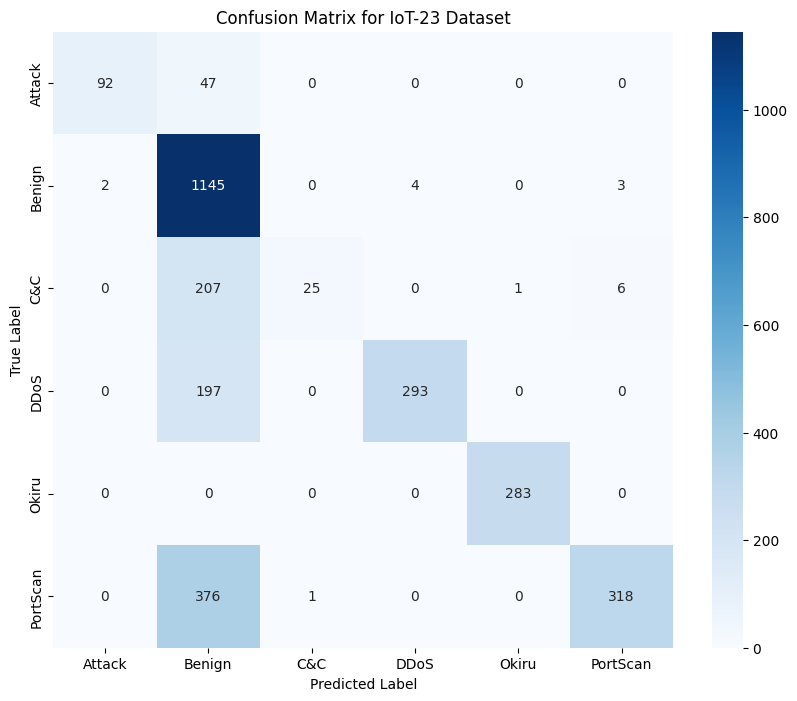

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, predictions, labels=np.unique(y_test))

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_for_report, yticklabels=target_names_for_report)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for IoT-23 Dataset')
plt.show()

In [ ]:
from sklearn.metrics import recall_score

# Define hyperparameter search space
max_depth_options = [4, 6, 8]
num_projections_options = [15, 20, 25]

best_recall_cc = -1
best_params = {}

print("Starting hyperparameter tuning...")

for depth in max_depth_options:
    for projections in num_projections_options:
        print(f"\nTraining with max_depth={depth}, num_projections={projections}...")

        # Initialize and train SLM with current hyperparameters
        slm_tuned = SubspaceLearningMachine(
            max_depth=depth,
            min_samples=10, # Keep min_samples constant for now
            num_projections=projections,
            beta=0.5 # Keep beta constant for now
        )
        slm_tuned.fit(X_train, y_train)

        # Make predictions
        tuned_predictions = slm_tuned.predict(X_test)

        # Calculate recall for C&C class
        # Find the integer label for 'C&C'
        cc_label_index = np.where(label_encoder.classes_ == 'C&C')[0]
        if len(cc_label_index) == 0:
            print("C&C label not found in encoder. Skipping recall calculation.")
            continue
        cc_label = label_encoder.transform(['C&C'])[0]

        # Explicitly binarize y_test and tuned_predictions for C&C class
        y_true_cc_binary = (y_test == cc_label)
        y_pred_cc_binary = (tuned_predictions == cc_label)

        # Handle case where there are no true C&C samples to avoid division by zero or NaN issues
        if np.sum(y_true_cc_binary) == 0:
            recall_cc = 0.0 # If no true C&C, recall is 0
        else:
            # Calculate recall for the binary case (C&C is positive class = True)
            recall_cc = recall_score(y_true_cc_binary, y_pred_cc_binary, pos_label=True)

        print(f"C&C Recall: {recall_cc:.4f}")

        if recall_cc > best_recall_cc:
            best_recall_cc = recall_cc
            best_params = {'max_depth': depth, 'num_projections': projections}

print("\nHyperparameter tuning complete.")
print(f"Best C&C Recall: {best_recall_cc:.4f} with parameters: {best_params}")

Starting hyperparameter tuning...

Training with max_depth=4, num_projections=15...
C&C Recall: 0.0000

Training with max_depth=4, num_projections=20...
C&C Recall: 0.0000

Training with max_depth=4, num_projections=25...
C&C Recall: 0.0000

Training with max_depth=6, num_projections=15...
C&C Recall: 0.0000

Training with max_depth=6, num_projections=20...
C&C Recall: 0.0000

Training with max_depth=6, num_projections=25...
C&C Recall: 0.5858

Training with max_depth=8, num_projections=15...
C&C Recall: 0.5858

Training with max_depth=8, num_projections=20...
C&C Recall: 0.9833

Training with max_depth=8, num_projections=25...
C&C Recall: 0.5816

Hyperparameter tuning complete.
Best C&C Recall: 0.9833 with parameters: {'max_depth': 8, 'num_projections': 20}
